# Single-/two-exon model burden with and without ULC/Kinnex models (HPC)

Goal: quantify whether CAT's additional model burden is enriched for one- or two-exon transcript models, and repeat after excluding `unknown_likely_coding` CAT models.

This notebook expects per-assembly `gff_compare/tx_metrics.tsv` outputs from `compare_gff_features.py`.

Expected copy-back folder after completion: `results/intermediate_spreadsheets/exon_count_ulc_sensitivity/`.


In [11]:
from pathlib import Path
from collections import Counter
import gc
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUTPUT_DIR = Path(os.getenv('HPRC_QC_OUTPUT_DIR', '/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results'))
QC_DIR = OUTPUT_DIR / 'qc_metrics'
WORK_DIR = OUTPUT_DIR / 'intermediate_spreadsheets' / 'exon_count_ulc_sensitivity'
FIG_DIR = WORK_DIR / 'figures'
PARTIAL_DIR = WORK_DIR / 'partials'
WORK_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
PARTIAL_DIR.mkdir(parents=True, exist_ok=True)

print('OUTPUT_DIR:', OUTPUT_DIR)
print('QC_DIR:', QC_DIR, QC_DIR.exists())
print('WORK_DIR:', WORK_DIR)
print('PARTIAL_DIR:', PARTIAL_DIR)


OUTPUT_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results
QC_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics True
WORK_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/intermediate_spreadsheets/exon_count_ulc_sensitivity
PARTIAL_DIR: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/intermediate_spreadsheets/exon_count_ulc_sensitivity/partials


In [12]:
# Locate tx_metrics files.
tx_files = sorted(QC_DIR.rglob('gff_compare/tx_metrics.tsv'))
if not tx_files:
    tx_files = sorted(QC_DIR.rglob('tx_metrics.tsv'))
print('tx_metrics files:', len(tx_files))
print('\n'.join(map(str, tx_files[:5])))
if not tx_files:
    raise FileNotFoundError('No tx_metrics.tsv files found. Need GFF_COMPARE outputs from the pipeline.')


tx_metrics files: 462
/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466835.2/gff_compare/tx_metrics.tsv
/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466845.2/gff_compare/tx_metrics.tsv
/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466855.2/gff_compare/tx_metrics.tsv
/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466985.2/gff_compare/tx_metrics.tsv
/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018467005.2/gff_compare/tx_metrics.tsv


In [13]:
# Aggregate with bounded memory and per-file checkpoints.
# Each tx_metrics.tsv is streamed in chunks and reduced to a tiny count table.
# If the job is killed, rerun the notebook and completed partials are skipped.
USECOLS = ['assembly_accession','sample_name','source','biotype','biotype_group','n_exons']
ULC_VALUE = 'unknown_likely_coding'
CHUNKSIZE = int(os.getenv('EXON_COUNT_CHUNKSIZE', '250000'))

GROUP_COLS = ['analysis_set','assembly_accession','sample_name','source','biotype_group','exon_class']
EXON_DTYPE = pd.CategoricalDtype(['1 exon', '2 exons', '>=3 exons', 'unknown'], ordered=True)


def partial_name(fp):
    # Parent is normally the assembly accession directory under qc_metrics.
    # Include the immediate parent as a fallback in case the path layout differs.
    accession = Path(fp).parents[1].name if Path(fp).parent.name == 'gff_compare' else Path(fp).parent.name
    stem = str(accession).replace('/', '_')
    return PARTIAL_DIR / f'{stem}.exon_class_counts.tsv'


def classify_exons(n_exons):
    n = pd.to_numeric(n_exons, errors='coerce')
    return pd.Series(
        np.select(
            [n.eq(1), n.eq(2), n.ge(3)],
            ['1 exon', '2 exons', '>=3 exons'],
            default='unknown'
        ),
        index=n_exons.index,
        dtype=EXON_DTYPE,
    )


def aggregate_chunk(chunk, analysis_set, counter):
    if chunk.empty:
        return
    work = pd.DataFrame({
        'analysis_set': analysis_set,
        'assembly_accession': chunk['assembly_accession'].astype('string').fillna('unknown'),
        'sample_name': chunk['sample_name'].astype('string').fillna('unknown'),
        'source': chunk['source'].astype('string').fillna('unknown'),
        'biotype_group': chunk['biotype_group'].astype('string').fillna(chunk['biotype'].astype('string')).fillna('unknown'),
        'exon_class': classify_exons(chunk['n_exons']),
    })
    grouped = work.groupby(GROUP_COLS, observed=True).size()
    counter.update({tuple(k): int(v) for k, v in grouped.items()})


def aggregate_one_file(fp, out_tsv):
    counter = Counter()
    for chunk in pd.read_csv(fp, sep='	', usecols=lambda c: c in USECOLS, chunksize=CHUNKSIZE):
        # Ensure optional columns exist even if an older tx_metrics schema is encountered.
        for col in USECOLS:
            if col not in chunk.columns:
                chunk[col] = pd.NA

        aggregate_chunk(chunk, 'all_models', counter)

        keep = ~((chunk['source'].astype('string') == 'CAT') & (chunk['biotype'].astype('string') == ULC_VALUE))
        aggregate_chunk(chunk.loc[keep], 'cat_excluding_unknown_likely_coding', counter)

        del chunk

    rows = [(*key, value) for key, value in counter.items()]
    out = pd.DataFrame(rows, columns=GROUP_COLS + ['n_transcripts'])
    out.sort_values(GROUP_COLS).to_csv(out_tsv, sep='	', index=False)
    return out_tsv


partials = []
for i, fp in enumerate(tx_files, 1):
    partial = partial_name(fp)
    partials.append(partial)
    if partial.exists() and partial.stat().st_size > 0:
        if i == 1 or i % 50 == 0:
            print(f'{i}/{len(tx_files)} skip existing {partial.name}', flush=True)
        continue
    print(f'{i}/{len(tx_files)} aggregating {fp}', flush=True)
    tmp = partial.with_suffix('.tmp')
    aggregate_one_file(fp, tmp)
    tmp.replace(partial)
    gc.collect()

print(f'Partial count files: {sum(p.exists() and p.stat().st_size > 0 for p in partials):,} / {len(partials):,}')

frames = [pd.read_csv(p, sep='	') for p in partials if p.exists() and p.stat().st_size > 0]
if not frames:
    raise RuntimeError('No partial count files were created.')
counts = pd.concat(frames, ignore_index=True)
counts = (counts.groupby(GROUP_COLS, observed=True)['n_transcripts']
          .sum().reset_index())
counts.to_csv(WORK_DIR / 'exon_class_counts_per_assembly.tsv', sep='	', index=False)
print('counts:', counts.shape)
display(counts.head())


1/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466835.2/gff_compare/tx_metrics.tsv
2/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466845.2/gff_compare/tx_metrics.tsv
3/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466855.2/gff_compare/tx_metrics.tsv
4/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018466985.2/gff_compare/tx_metrics.tsv
5/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018467005.2/gff_compare/tx_metrics.tsv
6/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018467015.2/gff_compare/tx_metrics.tsv
7/462 aggregating /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/qc_metrics/GCA_018467155.2/gff_compare/tx_metrics.tsv
8/462 aggregating /hps/nobackup/fl

,analysis_set,assembly_accession,sample_name,source,biotype_group,exon_class,n_transcripts
0,all_models,GCA_018466835.2,HG02257_mat,CAT,lncRNA,1 exon,8052
1,all_models,GCA_018466835.2,HG02257_mat,CAT,lncRNA,2 exons,53106
2,all_models,GCA_018466835.2,HG02257_mat,CAT,lncRNA,>=3 exons,137236
3,all_models,GCA_018466835.2,HG02257_mat,CAT,other,1 exon,2911
4,all_models,GCA_018466835.2,HG02257_mat,CAT,other,2 exons,752


In [14]:
# Median counts and percentage composition by assembly.
counts = pd.read_csv(WORK_DIR / 'exon_class_counts_per_assembly.tsv', sep='\t')
EXON_ORDER = ['1 exon','2 exons','>=3 exons','unknown']
SOURCE_ORDER = ['Ensembl','CAT']

# Percentages within assembly/source/biotype_group/analysis_set.
totals = counts.groupby(['analysis_set','assembly_accession','source','biotype_group'])['n_transcripts'].transform('sum')
counts['pct_within_source_biotype_assembly'] = np.where(totals > 0, 100 * counts['n_transcripts'] / totals, np.nan)
counts.to_csv(WORK_DIR / 'exon_class_counts_and_percentages_per_assembly.tsv', sep='\t', index=False)

med_counts = (counts.groupby(['analysis_set','source','biotype_group','exon_class'])['n_transcripts']
              .median().reset_index(name='median_n_transcripts_per_assembly'))
med_pct = (counts.groupby(['analysis_set','source','biotype_group','exon_class'])['pct_within_source_biotype_assembly']
           .median().reset_index(name='median_pct_within_source_biotype'))
summary = med_counts.merge(med_pct, on=['analysis_set','source','biotype_group','exon_class'], how='outer')
summary.to_csv(WORK_DIR / 'exon_class_median_summary.tsv', sep='\t', index=False)
display(summary.head())


,analysis_set,source,biotype_group,exon_class,median_n_transcripts_per_assembly,median_pct_within_source_biotype
0,all_models,CAT,lncRNA,1 exon,8171.0,4.176207
1,all_models,CAT,lncRNA,2 exons,52333.5,26.812513
2,all_models,CAT,lncRNA,>=3 exons,134810.5,68.986963
3,all_models,CAT,other,1 exon,2640.0,77.480867
4,all_models,CAT,other,2 exons,511.0,15.009513


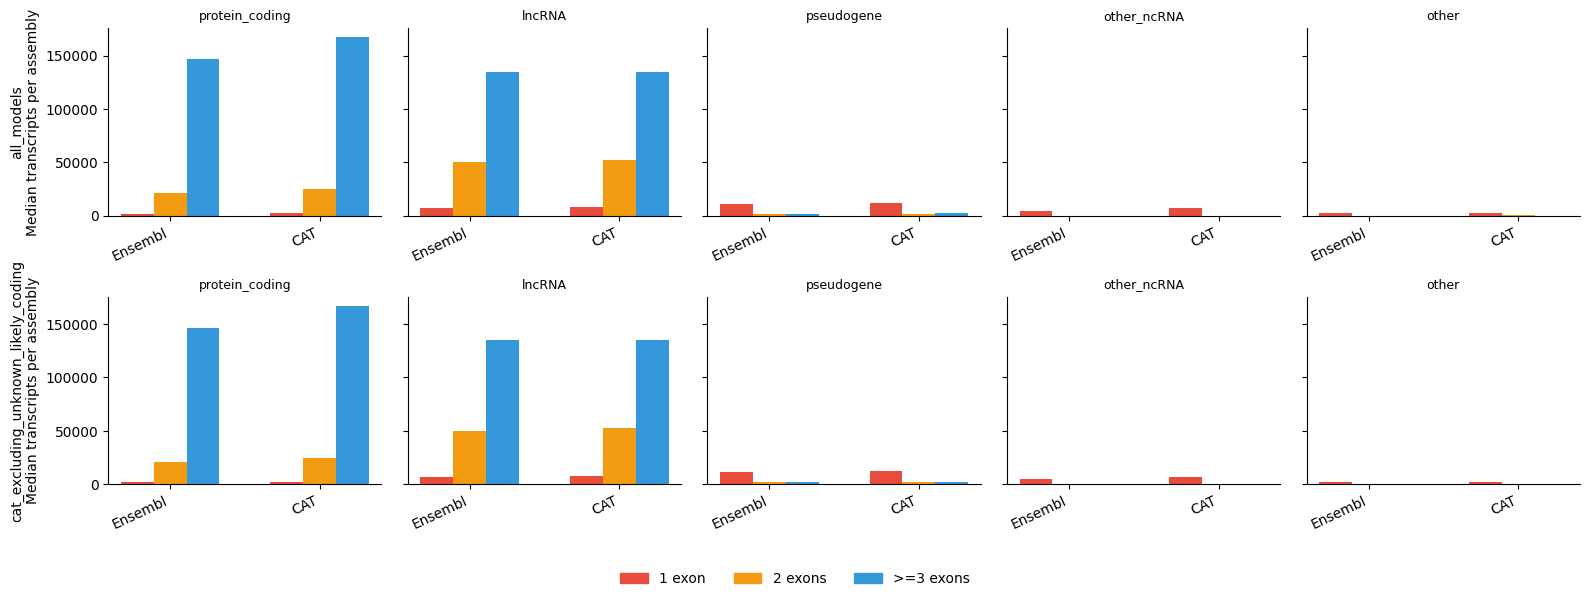

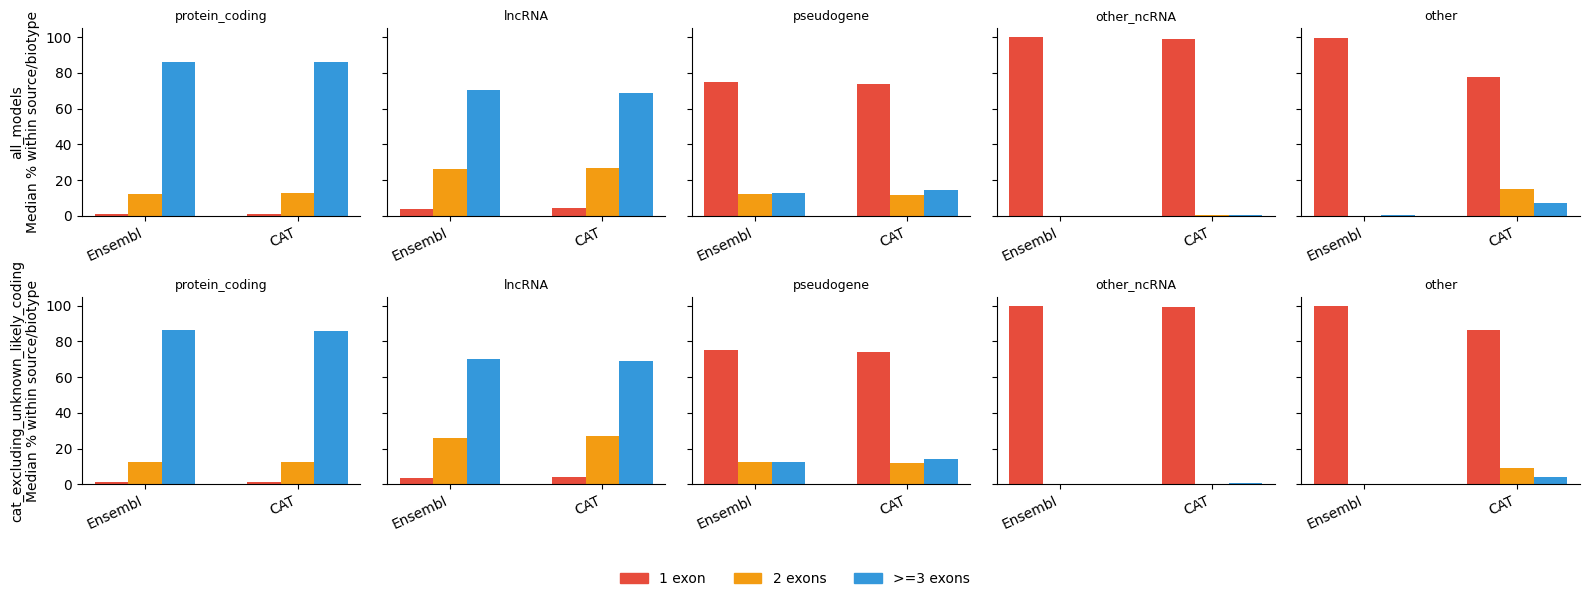

Copy back: /hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results/intermediate_spreadsheets/exon_count_ulc_sensitivity


In [15]:
# Render compact plots for protein_coding, lncRNA, pseudogene, and other_ncRNA.
summary = pd.read_csv(WORK_DIR / 'exon_class_median_summary.tsv', sep='\t')
BIOTYPES = ['protein_coding','lncRNA','pseudogene','other_ncRNA','other']
ANALYSES = ['all_models','cat_excluding_unknown_likely_coding']
EXON_ORDER = ['1 exon','2 exons','>=3 exons']
COLORS = {'1 exon':'#e74c3c', '2 exons':'#f39c12', '>=3 exons':'#3498db'}

for metric, ylabel, fname in [
    ('median_n_transcripts_per_assembly', 'Median transcripts per assembly', 'exon_class_median_counts'),
    ('median_pct_within_source_biotype', 'Median % within source/biotype', 'exon_class_median_percentages'),
]:
    fig, axes = plt.subplots(len(ANALYSES), len(BIOTYPES), figsize=(16, 6), sharey='row')
    for r, analysis in enumerate(ANALYSES):
        for c, bio in enumerate(BIOTYPES):
            ax = axes[r, c]
            sub = summary[(summary['analysis_set'] == analysis) & (summary['biotype_group'] == bio)]
            x = np.arange(2)
            width = 0.22
            for j, ex in enumerate(EXON_ORDER):
                vals = []
                for source in ['Ensembl','CAT']:
                    v = sub[(sub['source'] == source) & (sub['exon_class'] == ex)][metric]
                    vals.append(float(v.iloc[0]) if len(v) else 0.0)
                ax.bar(x + (j-1)*width, vals, width=width, color=COLORS[ex], label=ex)
            ax.set_title(bio, fontsize=9)
            ax.set_xticks(x); ax.set_xticklabels(['Ensembl','CAT'], rotation=25, ha='right')
            if c == 0:
                ax.set_ylabel(f'{analysis}\n{ylabel}')
            ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    handles = [mpatches.Patch(color=COLORS[e], label=e) for e in EXON_ORDER]
    fig.legend(handles=handles, loc='lower center', ncol=3, frameon=False)
    plt.tight_layout(rect=[0,0.08,1,1])
    fig.savefig(FIG_DIR / f'{fname}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{fname}.pdf', bbox_inches='tight')
    plt.show()

print('Copy back:', WORK_DIR)
